# Comparaison Finale des Modèles

Ce notebook charge directement les modèles sauvegardés (.pkl et .keras)
et calcule toutes les métriques en temps réel sur le test set.

**Problématique 1 — Classification** : Prédire quel client va churner (variable `churn`)

**Problématique 2 — Régression** : Estimer le revenu à risque (variable `revenue_at_risk`)

**Modèles retenus :**
- Classification : **Random Forest** (Recall=0.848, ROC-AUC=0.802)
- Régression : **XGBoost** (MAE=49.28€, R²=0.981)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import shap

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

os.makedirs('../results', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Chargement des données de test

In [2]:
X_test     = np.load('../data/processed/X_test.npy')
y_test_clf = np.load('../data/processed/y_test_clf.npy')
y_test_reg = np.load('../data/processed/y_test_reg.npy')
feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f'X_test     : {X_test.shape}')
print(f'y_test_clf : {y_test_clf.shape} — {int(y_test_clf.sum())} churners ({y_test_clf.mean()*100:.1f}%)')
print(f'y_test_reg : {y_test_reg.shape}')
print(f'Features   : {len(feature_names)}')

X_test     : (2000, 50)
y_test_clf : (2000,) — 204 churners (10.2%)
y_test_reg : (2000,)
Features   : 50


## 2. Chargement et évaluation des modèles de classification

Métriques calculées sur le jeu de test, avec les seuils de décision optimisés et retenus
dans le rapport (cf. notebooks individuels) :
- **Random Forest / XGBoost** : seuil = 0.45 (optimisé pour maximiser le Recall)
- **Logistic Regression / MLP** : seuil = 0.5 (seuil par défaut, déjà optimal)

- **Recall** : métrique prioritaire (minimiser les churners manqués)
- **ROC-AUC** : performance discriminante globale
- **PR-AUC** : performance sur la classe minoritaire


In [3]:
# Seuils optimisés retenus (cf. notebooks individuels) :
# Random Forest et XGBoost -> seuil 0.45 (Recall optimisé)
# Logistic Regression et MLP -> seuil 0.5 (seuil par défaut, déjà optimal)
seuils = {
    'Logistic Regression': 0.5,
    'Random Forest':       0.45,
    'XGBoost':              0.45,
    'MLP':                  0.5,
}

clf_models = [
    ('Logistic Regression', '../models/lr_classification.pkl',  'sklearn'),
    ('Random Forest',       '../models/rf_classification.pkl',  'sklearn'),
    ('XGBoost',             '../models/xgb_classification.pkl', 'sklearn'),
    ('MLP',                 '../models/mlp_classification.keras', 'keras'),
]

clf_results = []
clf_probas  = {}

for model_name, path, mtype in clf_models:
    try:
        if mtype == 'sklearn':
            model   = joblib.load(path)
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            model   = tf.keras.models.load_model(path)
            y_proba = model.predict(X_test, verbose=0).flatten()

        seuil  = seuils[model_name]
        y_pred = (y_proba >= seuil).astype(int)
        clf_probas[model_name] = y_proba

        clf_results.append({
            'Modele'   : model_name,
            'seuil'    : seuil,
            'accuracy' : accuracy_score(y_test_clf, y_pred),
            'precision': precision_score(y_test_clf, y_pred, zero_division=0),
            'recall'   : recall_score(y_test_clf, y_pred),
            'f1'       : f1_score(y_test_clf, y_pred),
            'roc_auc'  : roc_auc_score(y_test_clf, y_proba),
            'pr_auc'   : average_precision_score(y_test_clf, y_proba),
        })
        print(f'OK {model_name} (seuil={seuil}) — Recall={clf_results[-1]["recall"]:.4f} | ROC-AUC={clf_results[-1]["roc_auc"]:.4f}')

    except Exception as e:
        print(f'ERREUR {model_name} : {e}')

df_clf = pd.DataFrame(clf_results)
print(f'\n{len(df_clf)} modèles évalués')


OK Logistic Regression (seuil=0.5) — Recall=0.6569 | ROC-AUC=0.7212
OK Random Forest (seuil=0.45) — Recall=0.8725 | ROC-AUC=0.8024
OK XGBoost (seuil=0.45) — Recall=0.8137 | ROC-AUC=0.7837
OK MLP (seuil=0.5) — Recall=0.7402 | ROC-AUC=0.7183

4 modèles évalués


## 3. Chargement et évaluation des modèles de régression

Évaluation uniquement sur les churners du test set (204 clients).

In [4]:
churners_mask = y_test_reg > 0

reg_models = [
    ('Ridge Regression',  '../models/lr_regression.pkl',   'sklearn'),
    ('Random Forest',     '../models/rf_regression.pkl',   'sklearn'),
    ('XGBoost',           '../models/xgb_regression.pkl',  'sklearn'),
    ('MLP',               '../models/mlp_regression.keras','keras'),
]

reg_results = []

for model_name, path, mtype in reg_models:
    try:
        if mtype == 'sklearn':
            model = joblib.load(path)
            y_pred_log = model.predict(X_test)
            # Ridge et RF utilisent log-transformation
            if model_name in ['Ridge Regression', 'Random Forest']:
                y_pred = np.maximum(np.expm1(y_pred_log), 0)
            else:
                # XGBoost prédit directement en euros
                y_pred = np.maximum(y_pred_log, 0)
        else:
            model = tf.keras.models.load_model(path)
            y_pred_log = model.predict(X_test[churners_mask], verbose=0).flatten()
            y_pred = np.maximum(np.expm1(y_pred_log), 0)
            # Pour MLP on évalue directement sur churners
            mae  = mean_absolute_error(y_test_reg[churners_mask], y_pred)
            rmse = np.sqrt(mean_squared_error(y_test_reg[churners_mask], y_pred))
            r2   = r2_score(y_test_reg[churners_mask], y_pred)
            reg_results.append({'Modele': model_name, 'mae': mae, 'rmse': rmse, 'r2': r2})
            print(f'OK {model_name} — MAE={mae:.2f}€ | R²={r2:.4f}')
            continue

        mae  = mean_absolute_error(y_test_reg[churners_mask], y_pred[churners_mask])
        rmse = np.sqrt(mean_squared_error(y_test_reg[churners_mask], y_pred[churners_mask]))
        r2   = r2_score(y_test_reg[churners_mask], y_pred[churners_mask])

        reg_results.append({'Modele': model_name, 'mae': mae, 'rmse': rmse, 'r2': r2})
        print(f'OK {model_name} — MAE={mae:.2f}€ | R²={r2:.4f}')

    except Exception as e:
        print(f'ERREUR {model_name} : {e}')

df_reg = pd.DataFrame(reg_results)
print(f'\n{len(df_reg)} modèles évalués')

OK Ridge Regression — MAE=261.51€ | R²=0.7968
OK Random Forest — MAE=181.89€ | R²=0.7911
OK XGBoost — MAE=49.28€ | R²=0.9810
OK MLP — MAE=383.45€ | R²=0.1592

4 modèles évalués


## 4. Tableau comparatif — Classification

In [5]:
df_clf_sorted = df_clf.sort_values('recall', ascending=False).reset_index(drop=True)

print('=' * 88)
print('COMPARAISON CLASSIFICATION — 4 MODÈLES (triés par Recall)')
print('=' * 88)
header = f"{'Modèle':<22} {'Seuil':>6} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9} {'PR-AUC':>8}"
print(header)
print('-' * 88)
for _, row in df_clf_sorted.iterrows():
    print(f"{row['Modele']:<22} {row['seuil']:>6.2f} {row['accuracy']:>9.4f} {row['precision']:>10.4f} {row['recall']:>8.4f} {row['f1']:>8.4f} {row['roc_auc']:>9.4f} {row['pr_auc']:>8.4f}")
print('-' * 88)

best_recall  = df_clf.loc[df_clf['recall'].idxmax()]
best_roc_auc = df_clf.loc[df_clf['roc_auc'].idxmax()]
best_f1      = df_clf.loc[df_clf['f1'].idxmax()]

print(f"\nMeilleur Recall  : {best_recall['Modele']} ({best_recall['recall']:.4f})")
print(f"Meilleur ROC-AUC : {best_roc_auc['Modele']} ({best_roc_auc['roc_auc']:.4f})")
print(f"Meilleur F1      : {best_f1['Modele']} ({best_f1['f1']:.4f})")


COMPARAISON CLASSIFICATION — 4 MODÈLES (triés par Recall)
Modèle                  Seuil  Accuracy  Precision   Recall       F1   ROC-AUC   PR-AUC
----------------------------------------------------------------------------------------
Random Forest            0.45    0.6955     0.2339   0.8725   0.3689    0.8024   0.2974
XGBoost                  0.45    0.7055     0.2315   0.8137   0.3605    0.7837   0.2662
MLP                      0.50    0.6215     0.1766   0.7402   0.2852    0.7183   0.2299
Logistic Regression      0.50    0.6685     0.1843   0.6569   0.2879    0.7212   0.2385
----------------------------------------------------------------------------------------

Meilleur Recall  : Random Forest (0.8725)
Meilleur ROC-AUC : Random Forest (0.8024)
Meilleur F1      : Random Forest (0.3689)


## 5. Visualisation — Classification

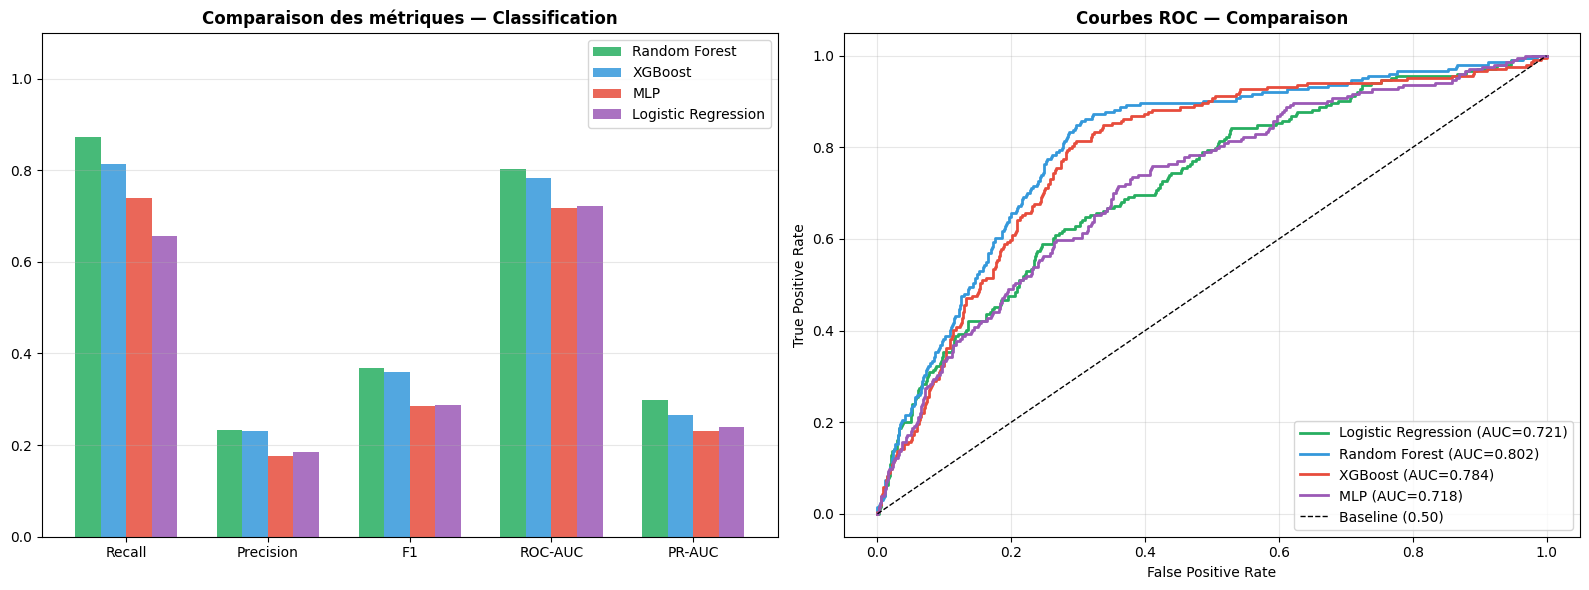

In [6]:
colors = ['#27ae60', '#3498db', '#e74c3c', '#9b59b6']
metrics = ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']
metric_labels = ['Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(metrics))
width = 0.18
for i, (_, row) in enumerate(df_clf_sorted.iterrows()):
    axes[0].bar(x + i * width, [row[m] for m in metrics],
                width, label=row['Modele'], color=colors[i], alpha=0.85)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metric_labels)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Comparaison des métriques — Classification', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Courbes ROC
for (model_name, path, mtype), color in zip(clf_models, colors):
    if model_name in clf_probas:
        fpr, tpr, _ = roc_curve(y_test_clf, clf_probas[model_name])
        auc = roc_auc_score(y_test_clf, clf_probas[model_name])
        axes[1].plot(fpr, tpr, color=color, linewidth=2, label=f'{model_name} (AUC={auc:.3f})')

axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Baseline (0.50)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbes ROC — Comparaison', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/comparaison_classification.png', dpi=150)
plt.show()

## 6. Tableau comparatif — Régression

In [7]:
df_reg_sorted = df_reg.sort_values('mae', ascending=True).reset_index(drop=True)

print('=' * 65)
print('COMPARAISON RÉGRESSION — 4 MODÈLES (triés par MAE)')
print('=' * 65)
print(f"{'Modèle':<22} {'MAE (€)':>10} {'RMSE (€)':>10} {'R²':>8}")
print('-' * 65)
for _, row in df_reg_sorted.iterrows():
    print(f"{row['Modele']:<22} {row['mae']:>10.2f} {row['rmse']:>10.2f} {row['r2']:>8.4f}")
print('-' * 65)

best_mae = df_reg.loc[df_reg['mae'].idxmin()]
best_r2  = df_reg.loc[df_reg['r2'].idxmax()]
print(f"\nMeilleur MAE : {best_mae['Modele']} ({best_mae['mae']:.2f}€)")
print(f"Meilleur R²  : {best_r2['Modele']} ({best_r2['r2']:.4f})")

COMPARAISON RÉGRESSION — 4 MODÈLES (triés par MAE)
Modèle                    MAE (€)   RMSE (€)       R²
-----------------------------------------------------------------
XGBoost                     49.28     130.96   0.9810
Random Forest              181.89     434.38   0.7911
Ridge Regression           261.51     428.48   0.7968
MLP                        383.45     871.55   0.1592
-----------------------------------------------------------------

Meilleur MAE : XGBoost (49.28€)
Meilleur R²  : XGBoost (0.9810)


## 7. Visualisation — Régression

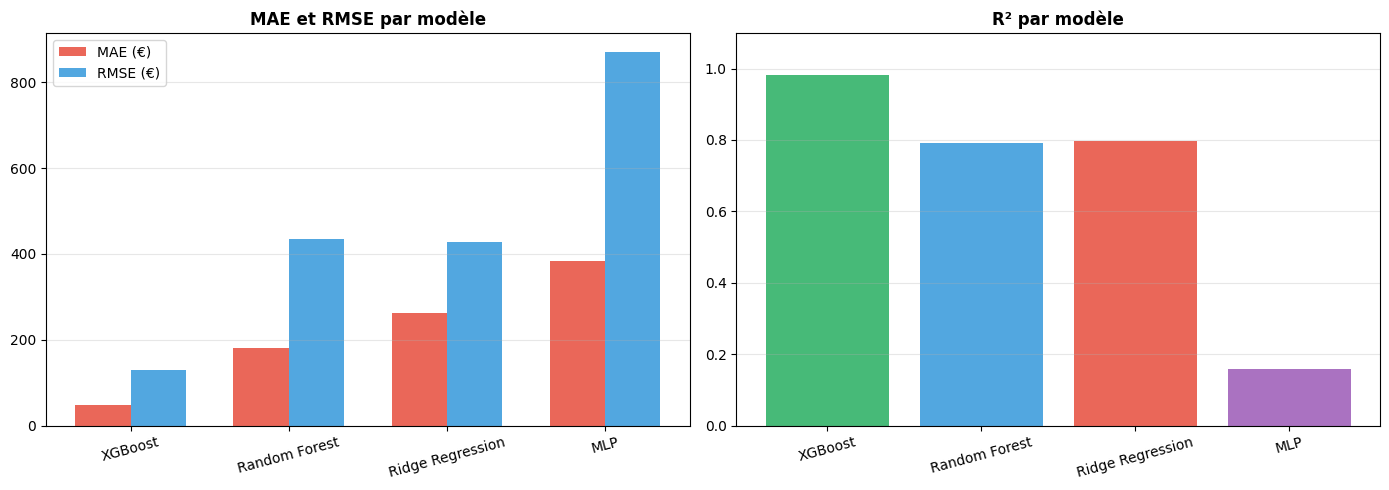

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_reg = df_reg_sorted['Modele'].tolist()
colors_reg = ['#27ae60', '#3498db', '#e74c3c', '#9b59b6']

x = np.arange(len(models_reg))
width = 0.35
axes[0].bar(x - width/2, df_reg_sorted['mae'],  width, label='MAE (€)',  color='#e74c3c', alpha=0.85)
axes[0].bar(x + width/2, df_reg_sorted['rmse'], width, label='RMSE (€)', color='#3498db', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_reg, rotation=15)
axes[0].set_title('MAE et RMSE par modèle', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, df_reg_sorted['r2'], color=colors_reg[:len(models_reg)], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_reg, rotation=15)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('R² par modèle', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/comparaison_regression.png', dpi=150)
plt.show()

## 8. Analyse SHAP — Random Forest (modèle retenu classification)

SHAP (SHapley Additive exPlanations) permet d'expliquer les prédictions du modèle :
- **Global** : quelles variables influencent le plus le modèle en général ?
- **Local** : pourquoi ce client précis a-t-il une probabilité de churn élevée ?

In [9]:
# Chargement RF
rf_clf = joblib.load('../models/rf_classification.pkl')

# Échantillon 500 clients pour SHAP
np.random.seed(42)
idx_sample = np.random.choice(len(X_test), 500, replace=False)
X_sample   = X_test[idx_sample]

# Calcul SHAP
explainer   = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_sample)

# Pour classification binaire : prendre la classe 1
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
elif shap_values.ndim == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values

print(f'SHAP calculé sur {len(X_sample)} clients')
print(f'Shape SHAP values : {shap_vals.shape}')

SHAP calculé sur 500 clients
Shape SHAP values : (500, 50)


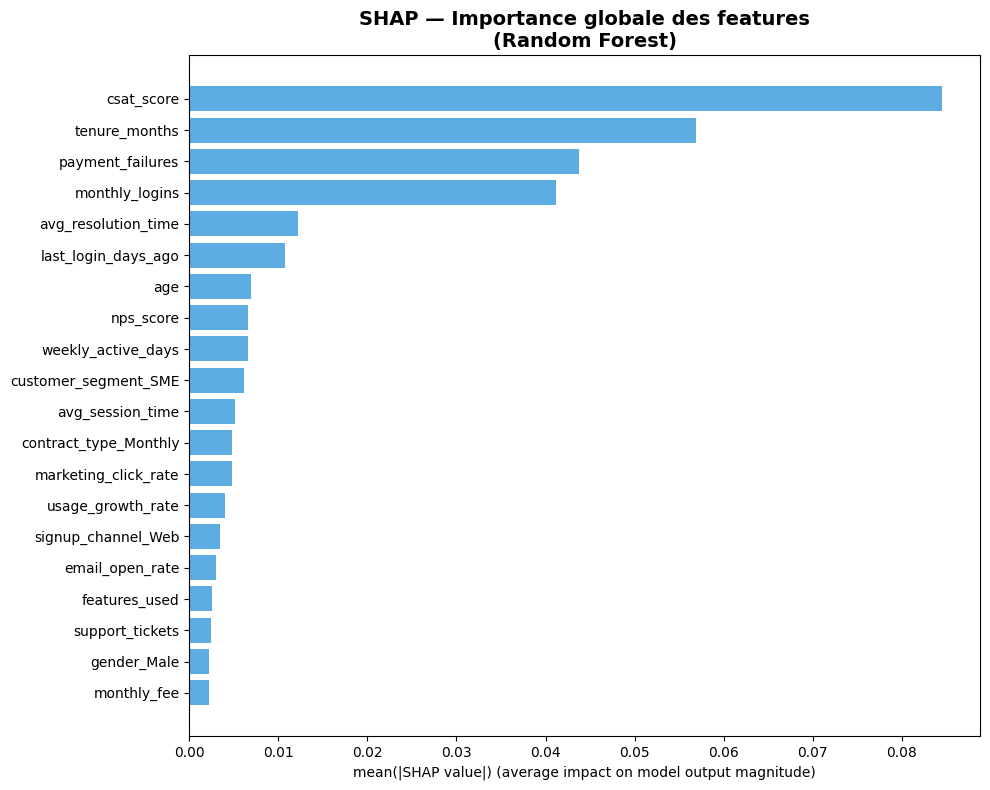


Top 10 features (SHAP) :
  1. csat_score                          : 0.0845
  2. tenure_months                       : 0.0569
  3. payment_failures                    : 0.0438
  4. monthly_logins                      : 0.0412
  5. avg_resolution_time                 : 0.0122
  6. last_login_days_ago                 : 0.0107
  7. age                                 : 0.0070
  8. nps_score                           : 0.0066
  9. weekly_active_days                  : 0.0066
  10. customer_segment_SME                : 0.0061


In [10]:
# SHAP Global — Importance des features
shap_importance = np.abs(shap_vals).mean(axis=0)
top_idx = np.argsort(shap_importance)[::-1][:20]

plt.figure(figsize=(10, 8))
plt.barh(
    range(20),
    shap_importance[top_idx][::-1],
    color='#3498db', alpha=0.8
)
plt.yticks(range(20), [feature_names[i] for i in top_idx][::-1], fontsize=10)
plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)')
plt.title('SHAP — Importance globale des features\n(Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/shap_global.png', dpi=150)
plt.show()

print('\nTop 10 features (SHAP) :')
for i in range(10):
    print(f'  {i+1}. {feature_names[top_idx[i]]:<35} : {shap_importance[top_idx[i]]:.4f}')

Client à risque élevé sélectionné : probabilité de churn = 84.7%


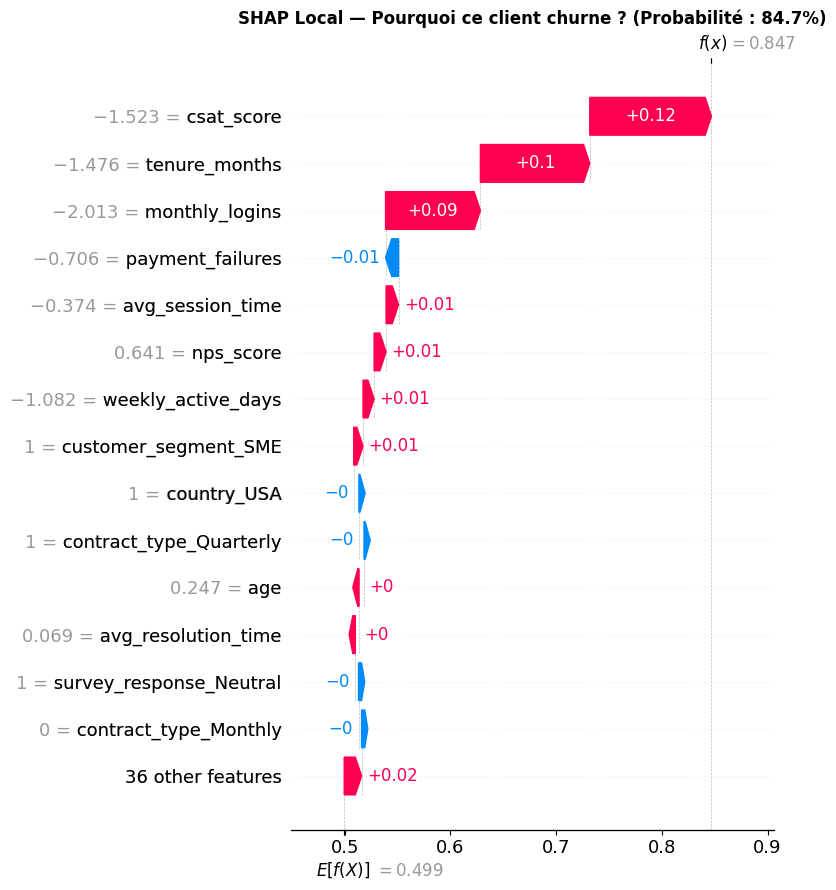

In [11]:
# SHAP Local — Explication d'un client à risque élevé
y_proba_sample = rf_clf.predict_proba(X_sample)[:, 1]
idx_high_risk  = np.argmax(y_proba_sample)
proba_high     = y_proba_sample[idx_high_risk]

print(f'Client à risque élevé sélectionné : probabilité de churn = {proba_high:.1%}')

# Fix : base_values scalaire
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = float(base_val[1])
else:
    base_val = float(base_val)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals[idx_high_risk],
        base_values=base_val,  # ← scalaire
        data=X_sample[idx_high_risk],
        feature_names=feature_names
    ),
    max_display=15,
    show=False
)
plt.title(f'SHAP Local — Pourquoi ce client churne ? (Probabilité : {proba_high:.1%})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/shap_local.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Synthèse finale et recommandations

In [12]:
best_clf = df_clf.loc[df_clf['recall'].idxmax()]
best_reg = df_reg.loc[df_reg['mae'].idxmin()]
revenu_total_risque = 862640

print('=' * 70)
print('SYNTHÈSE FINALE')
print('=' * 70)

print('\nPROBLÉMATIQUE 1 — CLASSIFICATION')
print('-' * 70)
print(f"Modèle recommandé : {best_clf['Modele']}")
print(f"  Recall    : {best_clf['recall']:.4f}")
print(f"  Precision : {best_clf['precision']:.4f}")
print(f"  F1-Score  : {best_clf['f1']:.4f}")
print(f"  ROC-AUC   : {best_clf['roc_auc']:.4f}")
print(f"  PR-AUC    : {best_clf['pr_auc']:.4f}")

print('\nPROBLÉMATIQUE 2 — RÉGRESSION')
print('-' * 70)
print(f"Modèle recommandé : {best_reg['Modele']}")
print(f"  MAE  : {best_reg['mae']:.2f} €")
print(f"  RMSE : {best_reg['rmse']:.2f} €")
print(f"  R²   : {best_reg['r2']:.4f}")

SYNTHÈSE FINALE

PROBLÉMATIQUE 1 — CLASSIFICATION
----------------------------------------------------------------------
Modèle recommandé : Random Forest
  Recall    : 0.8725
  Precision : 0.2339
  F1-Score  : 0.3689
  ROC-AUC   : 0.8024
  PR-AUC    : 0.2974

PROBLÉMATIQUE 2 — RÉGRESSION
----------------------------------------------------------------------
Modèle recommandé : XGBoost
  MAE  : 49.28 €
  RMSE : 130.96 €
  R²   : 0.9810


## 10. Impact business — Revenu potentiellement protégé

In [13]:
revenu_total_risque = 862640

df_impact = df_clf[['Modele', 'recall']].copy()
df_impact['revenu_protege'] = (df_impact['recall'] * revenu_total_risque).round(0)
df_impact['revenu_manque']  = ((1 - df_impact['recall']) * revenu_total_risque).round(0)
df_impact = df_impact.sort_values('recall', ascending=False).reset_index(drop=True)

print('=' * 70)
print('IMPACT BUSINESS — REVENU POTENTIELLEMENT PROTÉGÉ')
print('=' * 70)
print(f"Revenu total à risque : {revenu_total_risque:,} €\n")
print(f"{'Modèle':<22} {'Recall':>8} {'Protégé (€)':>14} {'Manqué (€)':>13}")
print('-' * 70)
for _, row in df_impact.iterrows():
    print(f"{row['Modele']:<22} {row['recall']:>8.3f} {row['revenu_protege']:>14,.0f} {row['revenu_manque']:>13,.0f}")

gain = df_impact['revenu_protege'].max() - df_impact['revenu_protege'].min()
print(f"\nGain meilleur vs moins bon : +{gain:,.0f} €")

IMPACT BUSINESS — REVENU POTENTIELLEMENT PROTÉGÉ
Revenu total à risque : 862,640 €

Modèle                   Recall    Protégé (€)    Manqué (€)
----------------------------------------------------------------------
Random Forest             0.873        752,696       109,944
XGBoost                   0.814        701,952       160,688
MLP                       0.740        638,523       224,117
Logistic Regression       0.657        566,636       296,004

Gain meilleur vs moins bon : +186,060 €
